 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.26 (Backup)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

<img align="centre" width="900" height="900"  src="images/di.png"  >

In [1]:
# Unlike the other modules, we have been working so far, you have to download and install...
# To install this library in Jupyter notebook
import sys
!{sys.executable} -m pip install -q --upgrade pip
!{sys.executable} -m pip install -q statistics statsmodels scipy

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import math as m
import statistics
import scipy.stats as st
import statsmodels as sm

## Learning agenda of this notebook

**Bayesian Learning Part-I: (Maths Behind Naïve Bayes')**

- What is Probability?
- Some Important Terms related to Probability
- Types of Events
- Probability
- Van Diagram vs Contigency Tables
- Types of Probability
    - Joint Probability
    - Marginal/Simple/Unconditional Probability
    - Conditional Probability
- Bayes' Theorem
- Overview of Naïve Bayes' Classifier
    - Examples
    - Types of Naïve Bayes model under the scikit-learn library
        - `BernoulliNB`
        - `MultinomialNB`
        - `GaussianNB`

<br><br><br>
<font face = "Garamond" color=red size=4>**Bayesian Learning Part-II: Bernoulli Naïve Bayes' Classifier (Binary and Multinomial)**<br>
<font face = "Garamond" color=red size=4>- Toy example with One input feature<br>
<font face = "Garamond" color=red size=4>- Toy example with multiple input features<br>
<font face = "Garamond" color=red size=4>- Using ScikitLearn<br>

    
<font face = "Garamond" color=red size=4>**Bayesian Learning Part-III: Multinomial Naïve Bayes' Classifier (Binary and Multinomial)**<br>
<font face = "Garamond" color=red size=4>- Toy example with One input feature<br>
<font face = "Garamond" color=red size=4>- Toy example with multiple input features<br>
<font face = "Garamond" color=red size=4>- Using ScikitLearn<br>

    
<font face = "Garamond" color=red size=4>**Bayesian Learning Part-IV: Gaussian Naïve Bayes' Regressor**<br>
<font face = "Garamond" color=red size=4>- Toy example with One input feature<br>
<font face = "Garamond" color=red size=4>- Toy example with multiple input features<br>
<font face = "Garamond" color=red size=4>- Using ScikitLearn<br>

    
</font>

# <span style='background :lightgreen' > Section 1: (Overview of Probability for Machine Learning) </span>

# 1. Basic Terms Related to Probability
- **Random Experiment:** An experiment is called random experiment if it satisfies following two conditions:
    - It has more than two possible outcomes
    - It is not possible to predict the outcome in advance
- **Trial:** It refers to a single execution of a random experiment. Each trial produces an outcome
- **Outcome:** It refers to a single possible result of a trial.
- **Sample Space:** It is the set of all possible outcomes that can occur. Generally one random experiment will have one set of sample space.
- **Event:**  Event is a specific set of outcomes from a RE or process. Essentially it's a subset of sample space. An event can include a single outcome or multiple outcomes. One random experiment can have multiple events. Events can be of following types:
    - **Simple Event:** A simple event is an event that consists of exactly one outcome, e.g., rolling a fair dice and getting a three {3}.
    - **Compound Event:** A compound event consist of two or more simple events,  e.g., rolling a fair dice and getting an odd number {1, 3, 5}
    - **Independent Events:** Two events are said to be independent, when the occurrence of one event DOES NOT affect the probability of occurance of other event. For example, flipping a coin and rolling a die are two independent events. Similarly, drawing two cards with replacement from a deck of cards.
    - **Dependent Events:** Two events are said to be dependent, if they happen one after another, and the occurrence of one event DOES affect the probability of occurrence of other event. For example, drawing two cards without replacement from a deck of cards.
    - **Mutually Exclusive Events:** Two events are mutually exclusive (disjoint), if they cannot both occur at the same time. For example, when you roll a die getting a 2 or getting a 6 are two mutually exclusive events.
   
   
   
### Examples:
- **Tossing a coin:**
- **Rolling a dice:**
    - Random Experiment: Rolling a dice
    - Trial: Rolling a dice once
    - Outcome: {3}
    - Sample Space: {1,2,3,4,5,6} 
    - Event:  getting a 3 {3}, getting a number greater than 4 {5,6}, getting an odd number {1,3,5}
- **Tossing a coin twice:**
    - Random Experiment: Tossing a Coin twice
    - Trial: Tossing a coin twice (once)
    - Outcome: {H,T}
    - Sample Space: {(HH), (TH), (HT), (TT)}
    - Event: getting two heads {(HH)}, getting atleast one head{((HH), (TH), (HT)}
    

<img align="right" width="600"  src="images/titanicimg.png"  >

- **Titanic Dataset:**
    - Random Experiment: Randomly drawing out a passenger and finding its pclass
    - Trial: Randomly drawing out a passenger and finding its pclass
    - Outcome: {1}
    - Sample Space: {1, 2, 3}
    - Event: getting a passenger belonging to pclass 2: {2}, getting a passenger NOT belonging to pclass 2: {1, 3}

<img align="right" width="400"  src="images/prob1.png"  >

# 2. What is Probability?
- Probability theory is a branch of mathematics concerned with the analysis of random phenomena, and defines the `likelihood of occurrence of an event`. 
- **Emperical/Experimental Probability:**
    - It is a probability measure that is based on observed/past data. It is calculated as the ratio of the number of times a particular event occurs to the total number of trials. Suppose we toss a coin hundred times and get heads 60 times and tails 40 times. The emperical probability of getting a head is: $ P(H) = \large \frac{60}{100} \small = 0.6 $
    
- **Theoratical/Classical Probability:**
    - It is a probability measure that is used when you do not have past data and is based on theoratical assumptions. It is calculated as the ratio of the number of favorable outcomes to the total number of outcomes of an event. Consider a scenario of tossing a coin hundred times (without performing the experiment). The theoratical probability of getting a head is  : $ P(H) = \large \frac{50}{100} \small = 0.5 $


$$ P(\text{event}) = \frac{\text{Number of favourable outcomes}}{\text{Total outcomes in sample space}} $$


- The value of the probability of an event to happen can lie between 0 and 1 because the favorable number of outcomes can never cross the total number of outcomes. 
- When the probability of something approaches 1, then it means it is very likely, and when the probability of something approaches 0, then it means that it is very unlikely.
- To understand Probability, we normally start to predict the outcomes for the `tossing of coins`, `rolling of dice`, or `drawing a card from a pack of playing cards`.

<img align="center" width="400" height="200"  src="images/prob.gif"  > 

> **Marginal probability is the probability of a single event irrespective of all other events.**

- **Example 1:**
If we're only flipping the coin once, then there are only two possible outcomes in the sample space $\Omega$: it will either be H or T (using set notation, we could write this as $\Omega$ = {H, T}.
Therefore: $$ P(H) = \frac{1}{2} = 0.5 $$
Equally: $$ P(T) = \frac{1}{2} = 0.5 $$

> **When number of trials increases to infinity the results of emperical probability becomes very close  to theoratical probability (Law of large numbers).**
- For example, suppose you toss a coin ten times and the emperical probability of head comes out to be say $ P(H) = \frac{3}{10} = 0.3 $, but the theoratical probability of getting head is always $ P(H) = \frac{5}{10} = 0.5 $ irrespective of the number of trials.
- When we increase the number of trials to say one thousand the emperical probability get close and close to 0.5
- The **law of large numbers** states that the more experiments we run, the closer we will tend to get to the expected probability. 
- > **Note:** Above are the probabilities. This comply to the Law of Large Numbers which says that "as we increase the number of coin tosses, the probability of getting heads gets closer and closer to 50%. 

- **Example 2:** Consider a scenario of tossing a fair coin three times.
<img align="right" width="300"  src="images/sstossing3coins.png"  > 

    - Event A: Getting exactly two heads. 
$$ P(A) = \frac{3}{8} = 0.375 $$

    - Event B: Getting three consecutive heads. 
$$ P(B) = \frac{1}{8} = 0.125 $$
    - Event C: Getting at least two heads. 
$$ P(C) = \frac{4}{8} = 0.5 $$

In [81]:
# The binomial() method is used to draw samples from a binomial distribution, 
# where n is the number of flips and p is the probability.
import numpy as np
print(np.random.binomial(n=10, p=0.5)) #Emperical probability of getting heads when you toss a coin ten times

number_of_trials = np.array([5, 10, 50, 100, 200, 500, 1000, 10000]) 
heads_count = [np.random.binomial(n=a, p=0.5) for a in number_of_trials]

proportion_heads = heads_count/number_of_trials
print(proportion_heads)

4
[0.4    0.5    0.54   0.53   0.5    0.514  0.514  0.4875]


- **Example 3:** Consider a scenario of rolling two dices. 
<img align="right" width="300"  src="images/sstwodices.png"  > 

    - Event A: Getting a sum of 7
$$ P(A) = \frac{6}{36} = 0.1666 $$

    - Event B: Getting an odd sum. 
$$ P(B) = \frac{18}{36} = 0.5 $$
    - Event C: Getting a sum greater than 10. 
$$ P(C) = \frac{3}{36} = 0.0833 $$


In [ ]:
# The binomial() method is used to draw samples from a binomial distribution, 
# where n is the number of flips and p is the probability.
import numpy as np
np.random.binomial(n=10, p=0.5)

number_of_trials = np.array([5, 10, 50, 100, 200, 500, 1000, 10000]) 
heads_count = [np.random.binomial(n=a, p=0.5) for a in number_of_trials]

proportion_heads = heads_count/number_of_trials
print(proportion_heads)

<img align="right" width="400"  src="images/ssplayingcards.png"  > 

- **Example 4:** Consider drawing a single card from a standard deck of 52 playing cards (Clubs, Spades, Hearts, Diamonds). In this case, the number of possible outcomes in the sample space $\Omega$ is 52. 
     
     - Getting a `spades` card
    $$ P(\text{spades}) = \frac{13}{52} \approx 0.25 $$
    
     - Getting an `ace` card
    $$ P(\text{ace}) = \frac{4}{52} \approx 0.0769 $$

     - Getting a `ace of spades` card
    $$ P(\text{ace of spades}) = \frac{1}{52} \approx 0.019 $$

     - Getting a `King or Queen` card
    $$ P(\text{King OR Queen}) = \frac{8}{52} \approx 0.1538 $$

     - Getting a `card`
    $$ P(\text{card}) = \frac{52}{52} \approx 1 $$
    
     - Getting a `apple`
    $$ P(\text{apple}) = \frac{0}{52} = 0 $$

# 3. The Concept of Random Variable and Probability Distributions

## a. Random Variable
- In the context of Probability theory, a random variable is not a variable rather is a function. Based on some logic it transforms some input to some output.
- Its input is all the possible values of sample space of a random process and the output are corresponding real numbers based on some logic.
- **Example 1:**  Consider a random experiment of tossing a coin having a sample space of {H, T}. The random variable is a function that will map the sample space of {H, T} to say {1, 0}
- **Example 2:**  Consider a random experiment of rolling a die having a sample space of {1,2,3,4,5,6}. The random variable is a function that will map the sample space to {1,2,3,4,5,6}
- **Example 3:**  Consider a random experiment of rolling two dice together, and the event is getting a sum of 9. The sample space has 36 possible outcomes. The input to the random variable in this case are the sum of the two outcomes, i.e., {2,3,4,5,6,7,8,9,10,11,12}. The random variable is a function that will map these inputs {2,3,4,5,6,7,8,9,10,11,12} to say {0,0,0,0,0,0,0,1,1,1,1}
- **Example 4:**  Consider a random experiment of rolling two dice together, and the event is number on die-1 is greater than the number on die-2. The sample space has 36 possible outcomes. The input in this case are the two numbers. The random variable is a function that will map each input to a value of one when the first number is greater than the second number and zero otherwise.

- Types of Random Variables:
    - Discrete Random Variable: A discrete random variable is a variable which can take on only a countable number of distinct values like 0, 1, 2, 3, 4, 5…100, 1 million, etc. Some examples of discrete random variables include: The number of times a coin lands on tails after being flipped 20 times. The number of times a dice lands on the number 4 after being rolled 100 times. The number of defective widgets in a box of 50 widgets.

    - Continouous Random Variable: A continuous random variable is a variable which can take on an infinite number of possible values. Some examples of continuous random variables include: Weight of an animal, Height of a person, Time required to run a marathon. For example, the height of a person could be 60.2 inches, 65.2344 inches, 70.431222 inches, etc. There are an infinite amount of possible values for height.

**Examples of Random Variables:**
- One example of a discrete random variable is the number of items sold at a store on a certain day. Using historical sales data, a store could create a probability distribution that shows how likely it is that they sell a certain number of items in a day.
- Another example of a discrete random variable is the number of customers that enter a shop on a given day. Using historical data, a shop could create a probability distribution that shows how likely it is that a certain number of customers enter the store.
- Another example of a discrete random variable is the number of defective products produced per batch by a certain manufacturing plant. Using historical data on defective products, a plant could create a probability distribution that shows how likely it is that a certain number of products will be defective in a given batch.
- Another example of a discrete random variable is the number of traffic accidents that occur in a specific city on a given day. Using historical data, a police department could create a probability distribution that shows how likely it is that a certain number of accidents occur on a given day.
- Example of a continuous random variable is the weight of a certain animal like a dog. This is a continuous random variable because it can take on an infinite number of values. For example, a dog might weigh 30.333 pounds, 50.340999 pounds, 60.5 pounds, etc. In this case, we could collect data on the weight of dogs and create a probability distribution that tells us the probability that a randomly selected dog weighs between two different amounts.
- Another example of a continuous random variable is the height of a certain species of plant.This is a continuous random variable because it can take on an infinite number of values. For example, a plant might have a height of 6.5555 inches, 8.95 inches, 12.32426 inches, etc. In this case, we could collect data on the height of this species of plant and create a probability distribution that tells us the probability that a randomly selected plant has a height between two different values.
- Another example of a continuous random variable is the distance traveled by a certain wolf during migration season. This is a continuous random variable because it can take on an infinite number of values. For example, a wolf may travel 40.335 miles, 80.5322 miles, 105.59 miles, etc. In this scenario, we could collect data on the distance traveled by wolves and create a probability distribution that tells us the probability that a randomly selected wolf will travel within a certain distance interval.




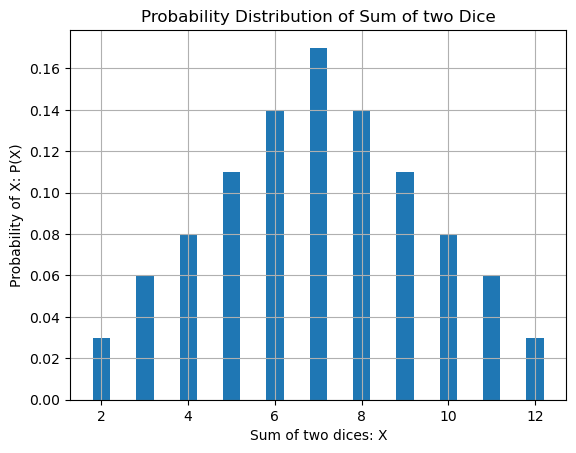

In [105]:
# creating a dataset containing list of students and their marks
mysum = [2,3,4,5,6,7,8,9,10,11,12]
prob = [0.03, 0.06, 0.08, 0.11, 0.14, 0.17, 0.14, 0.11, 0.08, 0.06, 0.03]


# Create figure and axes objects
fig = plt.figure()
ax = fig.add_subplot()

#Draw bar plot between names (categorical variable) and marks (numerical variable) of students
ax.bar(x=mysum, height=prob, width=0.4)

# adding labels
ax.set_xlabel("Sum of two dices: X")    # plt.xlabel("Names of Students")
ax.set_ylabel("Probability of X: P(X)")    # plt.ylabel("Marks of Students")



# adding title
ax.set_title("Probability Distribution of Sum of two Dice")     # plt.title("Distribution of Student Marks")
plt.grid(True)
plt.show()

## b. Probability Distribution
<center><font face = "Garamond" color=red size=4.5><div class="alert alert-success" style="margin: 10px">A probability distribution tells us the probability of all the possible values of a random variable, and sums up to 1</font></center>


    
- **Probability Distributions for Discrete Random Variables:** A discrete probability distribution, model the probabilities of random variables that can have discrete values as outcome, which are counted, not measured. For example, when a coin is tossed twice, the number of heads can be {0, 1, 2}, and not any value from 0 to 2 like 0.1 or 1.6. 
- **Probability Distributions for Continuous Random Variables:** A continuous probability distribution, model the probabilities of random variables that can have continuous values as outcome, which are measured, not counted.
- For example, the possible values for the random variable X that represents weights of citizens in a town can have any value like 34.5, 47.7, etc. 

### (i) Probability Distributions for Discrete Random Variable
- Consider a scenario of rolling two dice, with the sample space shown below
- Suppose the random variable is the sum of the two numbers that appeared on the two dice. The unique possible sums are {2,3,4,5,6,7,8,9,10,11,12}
- The frequency of the number 2 is 1, of number 3 is 2, number 4 is 3 and so on.

<img align="center" width="800" src="images/ss-twodice.png"  > 

<img align="center" width="800" src="images/prob_distr2.png"  > 

- The table above shows the probability distribution of random variable X, that tells us the probability of the unique values of random variable X.

- The left-hand column in the table shows the unique sum of the two dice and the right-hand column tells us the probability of that sum value. For example:
    - The probability that the sum is exactly 2: $P(X=2)=\large \frac{1}{36} \small =0.03$
    - The probability that the sum is exactly 3: $P(X=3)=\large \frac{2}{36} \small =0.06$
    - The probability that the sum is exactly 4: $P(X=4)=\large \frac{3}{36} \small =0.08$
    - The probability that the sum is exactly 5: $P(X=5)=\large \frac{4}{36} \small =0.11$
    - and so on....
- So the probability of getting a sum of 7 is maximum, while the probability of getting a sum of 2 and 12 is minimum.
- The easiest way to visualize the values in a probability distribution table is by using a histogram, which displays the values of the random variable along the x-axis and the probability of those values along the y-axis
- In this example of rolling two dice, there are just 11 unique values so we have shown it using bar graph. The graph of a discrete probability distribution are bars, with their heights representing the probability of that specific value.  
- There can be hundred or thousand different unique values, in which case we use a histogram instead. 

- One of the important property of distribution table is that all individual probabilities must add up to 1.  This can be verified from this table.

- **Mean of a Random Variable:** The mean of a random variable, often called the Expected Value is the weighted average of the possible outcomes of random variable, where outcome is weighted by its probability of occurrence.
- To find the mean (expected value) of a random variable, you simply multiply every possible outcome of the random variable with its corresponding probability. In this example the mean comes out to be 7. This means that when if you perform this experiment (i.e., rolling two dice a large number of times and taking their sum) the mean of all those trials will be 7.
- So to find the expected value of random variable X, you multiply the value of x with its probability and then take the sum of all the trials.
- a dice say he mean of a discrete random variable X is a weighted average of the possible values that the random variable can take. Unlike the sample mean of a group of observations, which gives each observation equal weight, the mean of a random variable weights each outcome xi according to its probability, pi. You simply multiply each possible outcome with its probability 

$$ E(x) = \mu  = \sum x_i p_i$$


- **Variance of a Random Variable:** The variance of a random variable is a statistical measurement that describes how much individual observations in a group differ from the mean (expected value). 'OR' how spread out the data is around the center of the distribution (the mean).  
- The formula to compute normal variance is:

$$ \large \sigma_x^2  = \frac{\sum(x_i - \mu)^2}{n-1}$$
- In the last column of the table, the value $(x_i - \mu)^2$ is the squared distances of each value from the expected value. To calculate the weighted mean, we multiply each squared difference with its  corresponding proabability and then take the sum.

- Variance $\sigma_x^2$ of a random variable with values $x_1, x_2, x_3,\cdots, x_n$ occurring with probabilities $p_1, p_2, p_3,\cdots, p_n$ can be given as :

$$ \large \sigma_x^2  = \sum(x_i - \mu)^2)p_i$$


<br><br>
<img align="center" width="600" src="images/prob_distr3.png"  > 


- **Probability Mass Function:** Discrete probability distributions are usually described/expressed by a formula called Probability Mass Function, abbreviated as **pmf**. Or a frequency distribution table, which tells you the number of times the observation occurs in the data. 
- The number of possible values of X are discrete from 2 to 12, it can be many more. For that we need to come up with a a function called Probability Mass Function, abbreviated as **pmf**, in which when you plug in a value of X you get P(X). A pmf is nothing but mathematically describe the relationship between X and its corresponding probability. If the number of possible values of X are continuous, we call the function as Probability Density Function, abbreviated as **pdf**.
- Some important examples of discrete probability distributions are:
    - Binomial distribution
    - Multinomial distribution
    - Bernoulli distribution
    - Poisson distribution

### (ii) Probability Distributions for Continuous Random Variable

- A continuous probability distribution, model the probabilities of random variables that can have continuous values as outcome, which are measured, not counted.
- For example, the possible values for the random variable X that represents weights of citizens in a town can have any value like 34.5, 47.7, etc. 
- Continuous probability distributions are usually described/expressed by a formula called Probability Density Function, abbreviated as **pdf**.
- The graph of a continuous probability distribution is a curve. 
- Probability is represented by area under the curve.
- Area under the curve is given by a different function called the Cumulative Distribution Function, abbreviated as **cdf**.

<img align="right" width="300" height="150"  src="images/pdf.png"  > 

**Continuous Probability Distribution Graph:**
- This graph shows the probability distribution for a continuous variable `amount of tip` given by customers in a restaurant, which ranges from 0 to 10.0. 

**Continuous Probability Distribution Types:**

    - Normal/Gaussian distribution
    - Standard Normal distribution
    - Log Normal distribution
    - Exponential distribution
    - Student’s T distribution
    - Chi-square distribution









Note: 
- The entire area under the curve and above the x-axis is equal to one.
- Probability is found for intervals of x values rather than for individual x values.
- P(c < x < d) is the probability that the random variable X is in the interval between the values c and d. 
- P(x = c) = 0 The probability that x takes on any single individual value is zero. 
- P(c < x < d) is the same as P(c ≤ x ≤ d) because probability is equal to area.


<img align="right" width="500" height="400"  src="images/normaldistr1.png"  >

###  Guassian/Normal Distribution
- The `Gaussian` or `Normal` Distribution is given by Friedrich Gauss, also known as the `Bell Curve`.
- Guassian or Normal distribution is denoted as $\mathcal{N}(\mu, \sigma^2)$. 
- A normal distribution is known as the bell curve because it looks like a bell.
- The density curve is symmetrical
- Normal distribution is defined by its mean and standard deviation. 
- Normal distribution is centered about its mean, with standard deviation indicating its spread. 
- At point x, the height can be calculated with the following formula:

<img align="center" width="200" height="200"  src="images/normal.png"  >

Where,

    - μ = Mean Value
    - σ = Standard Distribution of probability.
    - If mean(μ) = 0 and standard deviation(σ) = 1, then this distribution is known to be normal distribution.
    - x = Normal random variable

- For normally distributed data:
    - 68.3% of observations are within 1 standard deviation from the mean (-1,1).
    - 95% of observations are within 2 standard deviations of the mean (-2,2).
    - 99.7% of observations are within 3 standard deviations of the mean, interval (-3,3). 


- Real World Examples:
    - Height of the Population of the world
    - Height of adult women
    - Height of adult men
    - Income distribution in countries economy among poor and rich
    - The sizes of females shoes
    - Weight of newly born babies range
    - Average report of Students based on their performance       

# 4. Overview of Vann Diagrams and Contingency Tables
<img align="right" width="500"  src="images/venn-diagram-1.png"  > 

- In probability, a Venn diagram is a figure with one or more circles inside a rectangle that describes logical relations between events. The rectangle in a Venn diagram represents the sample space or the universal set, that is, the set of all possible outcomes. A circle inside the rectangle represents an event, that is, a subset of the sample space. We consider the following Venn diagram involving two events, 𝐴 and 𝐵.
    - Green and purple regions represent event A. 
    - Blue and purple regions represent event B.
    - Purple regions represent event $A \cap B$
    - Green, Purple, and Blue regions represent event $A \cup B$.
    - Yellow region represent event $(A \cup B)'$
- Within each divided region of a Venn diagram, we can add data in one of the following ways:
    - the outcomes of the event,
    - the number of outcomes in the event,
    - the probability of the event.




- Contingency tables are a great way to classify outcomes and calculate different types of probabilities. These tables contain rows and columns that display bivariate frequencies of categorical data. Analysts also refer to contingency tables as crosstabulation (cross tabs), two-way tables, and frequency tables.
- A contingency table provides a way of portraying data that can facilitate calculating probabilities. The table helps in determining conditional probabilities quite easily. The table displays sample values in relation to two different variables that may be dependent on one another. 
- These tables are more flexible than they first appear because they allow you to answer a diverse set of probability questions. What are the joint, marginal, and conditional probabilities of events occurring?
- When using a contingency table to calculate different types of probabilities, it’s just a matter of determining which table values go in the numerator and denominator. All the information you need is right there in the table!



**Example 1:** 
- Consider a scenario of rolling a die. 
    - Event A: Getting a number of greater than equal to 4
    - Event B: Getting an even number
- Draw Venn Diagram and Contingency table for this scenario

<img align="center" width="800" src="images/rolling-die-1.png"  > 


$\hspace{2cm} P(A) = \large \frac{3}{6}$,
$\hspace{2cm} P(B) = \large \frac{3}{6}$,
$\hspace{2cm} P(A \cap B) = \large \frac{2}{6}$, 
$\hspace{2cm} P(A \cup B) = \large \frac{4}{6}$<br><br>
$\hspace{2cm} P(A \cup B) = P(A) +P(B)-P(A\cap B)=\large \frac{3}{6}\small+\large\frac{3}{6}\small-\large\frac{2}{6}\small=\large\frac{4}{6}\small=\large\frac{2}{3}$

**Example 2:** 
- A class contains 100 students; 70 of them like mathematics, 60 like physics, and 40 like both. 
    - Event A: Student like mathematics
    - Event B: Student like physics
- Draw Venn Diagram and Contingency table for this scenario

<img align="center" width="800" src="images/contingency-table1.png"  > 

- If a student is chosen at random, find the probability that he/she 
    - like mathematics $= P(A) = \large \frac{70}{100}$ 
    - like physics $= P(B) = \large \frac{60}{100}$
    - like both mathematics and physics $= P(A \cap B)= \large \frac{40}{100}$
    - like mathematics or physics $= P(A \cup B)= P(A) +P(B)-P(A\cap B)=\large \frac{70}{100}\small+\large \frac{60}{100}\small-\large \frac{40}{100}\small=\large \frac{90}{100}$
    - like mathematics but not physics $= \large \frac{30}{100}$
    - like physics but not mathematics $= \large \frac{20}{100}$
    - like neither physics nor mathematics $= \large \frac{10}{100}$

>- We know that the overlapping region in a Venn diagram represents the intersection of the events. We are given that 40 students belong to this intersection, since they like both mathematics and physics. 70 students like mathematics, and 40 of them also like physics. This tells us that the number of students who like mathematics only is 70-40=30. Similarly, we can deduce that 60-40=20 students like physics only. We note that the number 10 outside is to ensure that the sum of all values within the Venn diagram is equal to 100, since the class contains 100 students total. 

**Example 3:** Consider a scenario of rolling two dice. Also consider the random variable is the sum of the two numbers that appeared on the two dice.
<img align="center" width="800" src="images/ss-twodice.png"  > 

- Event A: Getting a sum of greater than equal to 5
- Event B: Getting an even number
- Draw Venn Diagram and Contingency table for this scenario



<img align="center" width="800" src="images/contingency-table2.png"  > 


**Example 4:** Suppose `Netflix` took a survey of their subscribers to determine people favourite movies. Load the following toy dataset and create contingency table using the Panda's `crosstab` method

In [153]:
import numpy as np
import pandas as pd
df = pd.read_csv('datasets/sample1.csv')
df

,movie,gender
0,Titanic,female
1,Titanic,male
2,Titanic,female
3,Titanic,female
4,Titanic,female
5,Brave Heart,male
6,Brave Heart,male
7,Brave Heart,female
8,The Terminator,male
9,The Terminator,female


>- Let X be a random variable associated with the `movie` and can take three different values
>- Let Y be a random variable associated with the `gender` and can take two values

- The `pd.crosstab()` method is also used for data restructuring and reshaping.
- It is normally used for quickly comparing categorical variables.
- The cross table is also known as contingency table, which is a matrix type table that displays the (multivariate) frequency distribution of variables.
```
pandas.crosstab(index, 
                columns, 
                aggfunc=None,
                values=None,
                margins=False, 
                normalize=False)
```
Where,
- `index`: array-like, Series, or list of arrays/Series (Values to group by in the rows)
- `columns`: array-like, Series, or list of arrays/Series (Values to group by in the columns)
- `values`: array-like, optional (Array of values to aggregate according to the factors. Requires aggfunc be specified)
- `aggfunc`: function, optional If specified, requires values be specified as well.
- `margins`: bool, default False, Add row/column margins (subtotals).
- `normalize`: bool, {‘all’, ‘index’, ‘columns’}, or {0,1}, default False (Normalize by dividing all values by the sum of values)

In [154]:
# Let us create a contingency table on the two columns of above dataset (movie, gender)
pd.crosstab(index=df['movie'], columns=df['gender'])

gender,female,male
movie,,
Brave Heart,1,2
The Terminator,1,3
Titanic,4,1


In [155]:
pd.crosstab(index=df['movie'], columns=df['gender'], margins=True)

gender,female,male,All
movie,,,
Brave Heart,1,2,3
The Terminator,1,3,4
Titanic,4,1,5
All,6,6,12


# 5. Types of Probability
- Joint Probability is the probability of two events occurring simultaneously.
- Marginal Probability is the probability of an event irrespective of the outcome of some other event.
- Conditional Probability is the probability of an event occurring given that another event has already occurred.


**Note: For two independent events:**
- $P(A \cap B) = P(A)P(B)$<br><br>

- $P(A|B) = \large \frac{P(A \cap B)}{P(B)} = \frac{P(A)P(B)}{P(B)} \small= P(A)$<br><br>

- $P(B|A) = \large \frac{P(A \cap B)}{P(A)} = \frac{P(A)P(B)}{P(A)} \small= P(B)$

**Note: For two dependent events:**
- $P(A \cap B) = P(A)P(B)$<br><br>

- $P(A|B) = \large \frac{P(A \cap B)}{P(B)} $<br><br>

- $P(B|A) = \large \frac{P(A \cap B)}{P(A)} $


**Note: For two mutually exclusive events:**
- $P(A \cap B) = 0$<br><br>

- $P(A|B) = 0 $<br><br>

- $P(B|A) = 0 $

## a. Joint Probability
<h3 align="center"><div class="alert alert-success" style="margin: 20px">Joint Probability is the probability of two events occurring simultaneously</h3>

- Let us suppose that we have two random variables X and Y. The joint probability of X and Y, denoted as $P(X=x, Y=y)$, is the probability that X takes the value x and Y takes the value y at the same time.

- In order to compute the probability of two independent events, we use `joint probability`, that is equal to the product of individual probabilities of the two events.

\begin{equation}
P(A \cap B) \hspace{0.2cm} = \hspace{0.5cm} P(A) \times P(B)
\end{equation}
- Suppose we rolled two dices, what is the probability of getting two sixes?

\begin{equation}
P(A \cap B) \hspace{0.2cm} = \hspace{0.2cm} P(A) \times P(B)  \hspace{0.2cm}= \hspace{0.2cm} \frac{1}{6} \times \frac{1}{6}\hspace{0.2cm}= \hspace{0.2cm}0.0277
\end{equation}
- **Examples of some independent events:**
- Owning a dog and driving a car
- Winning the lottery and running out of milk
- Taking a cab home and finding your favorite movie on cable


In [152]:
import numpy as np
import pandas as pd
df = pd.read_csv('datasets/titanic2.csv')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


>- Let X be a random variable associated with the `pclass` of a Titanic passenger and can take the values {1,2,3}
>- Let Y be a random variable associated with the `survived` status of a Titanic passenger and can take the values {0, 1} 

In [137]:
# Let us create a contingency table on the two columns of titanic dataset (survived, pclass)
pd.crosstab(index=df['survived'], columns=df['pclass'])

pclass,1,2,3
survived,,,
0,80,97,372
1,136,87,119


>-  The cell value of 80 tells us that there are 80 passengers who belong to pclass=1 and do not survived.
>-  The cell value of 136 tells us that there are 136 passengers who belong to pclass=1 and survived.
>- and so on....
>- Now this tells us the count, and to calculate the probability we simply has to divide this count with the total number of passenger onboard and i.e., 891 and you get 0.08978. which is the probability of a passenger belonging to class 1 and who do not survived. This is  what joint probability is, where you take more than one event and you calculate the probability of happening of both the events

**What is the joint probability of survival of a Titanic passenger of `pclass` 3?**
- Contingency tables really shine at highlighting joint probabilities because each cell displays the number of times events occurred together. Those cell values are the joint events for the numerator. The grand total is the number of outcomes for the denominator.
- Consequently, to calculate joint probabilities in a contingency table, take each cell count and divide by the grand total.
- For our example, the joint probability of a passenger belonging to class 1 and not surviving can be obtained by dividing the cell value (80) divided by the grand total (891).

- If a passenger is chosen at random, find the probability that he/she:<br><br>
    - belongs to `pclass 1` and `not survived`: $P(\text{pclass}=1, \text{survived}=0)=\large \frac{80}{891}\small=0.089787$ <br><br>
    - belongs to `pclass 2` and `not survived`: $P(\text{pclass}=2, \text{survived}=0)=\large \frac{97}{891}\small=0.108866$ <br><br>
    - belongs to `pclass 3` and `not survived`: $P(\text{pclass}=3, \text{survived}=0)\large \frac{372}{891}\small=0.417508$  <br><br>
    - belongs to `pclass 1` and `survived`: $P(\text{pclass}=1, \text{survived}=1)\large \frac{136}{891}\small=0.152637$  <br><br>
    - belongs to `pclass 2` and `survived`: $P(\text{pclass}=2, \text{survived}=1)\large \frac{87}{891}\small=0.097643$  <br><br>
    - belongs to `pclass 3` and `survived`: $P(\text{pclass}=3, \text{survived}=1)\large \frac{119}{891}\small=0.133558$

In [164]:
# by setting normalize='all', you get the joint probabilities instead of count
pd.crosstab(index=df['survived'], columns=df['pclass'], normalize='all')

pclass,1,2,3
survived,,,
0,0.089787,0.108866,0.417508
1,0.152637,0.097643,0.133558


>- Each of these six individual numbers (probabilities) is called joint probability, and all the six probabilities together is known as `Joint Probability Distribution`, and the sum of these six probability values will always be 1.

## b. Marginal/Simple/Unconditional Probability
<h3 align="center"><div class="alert alert-success" style="margin: 20px">Marginal Probability is the probability of an event irrespective of the outcome of some other event.</h3>
    
<h3 align="center"><div class="alert alert-success" style="margin: 20px">Marginal probability of a random variable is simply the probability of that variable taking a certain value, regardless of the values of other variables.</h3>

LEt us understand marginal probability using the same titanic example that we used to understand joint probability

In [156]:
import numpy as np
import pandas as pd
df = pd.read_csv('datasets/titanic2.csv')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


>- Let X be a random variable associated with the `pclass` of a Titanic passenger and can take the values {1,2,3}
>- Let Y be a random variable associated with the `survived` status of a Titanic passenger and can take the values {0, 1} 

In [159]:
# Let us create a contingency table on the two columns of titanic dataset (survived, pclass), with margins=True
# By setting the margins argument to True, we 
pd.crosstab(index=df['survived'], columns=df['pclass'], margins=True)

pclass,1,2,3,All
survived,,,,
0,80,97,372,549
1,136,87,119,342
All,216,184,491,891


- By setting the margins argument to True, we get a total value along the rows as well as along the columns. The value of 549 tells us the total passengers who died irrespective to the pclass, while the value of 342 tells us the total passenger who survived irrespective to the pclass. 
- Similarly, this value 216 tells us that the count of passengers who belong to pclass 1 irrespective of whether they died or survived. And 184 tells us that the count of passengers who belong to pclass 2 irrespective of whether they died or survived. And finally this 491 tells us that the count of passengers who belong to pclass 3 irrespective of whether they died or survived.


- In case if joint probability you consider both the events together, while in case of marginal probability of an event, you forget about any other event happending, i.e., consider only one event 
- In order to calculate the marginal probability, you simply divide these five numbers with 891. This can be achieved easily using normalize argument of the crosstab method

In [163]:
# by setting the margins=True and normalize='all', you will get both the joint as well as marginal probabilities
pd.crosstab(index=df['survived'], columns=df['pclass'], margins=True, normalize='all')

pclass,1,2,3,All
survived,,,,
0,0.089787,0.108866,0.417508,0.616162
1,0.152637,0.097643,0.133558,0.383838
All,0.242424,0.206510,0.551066,1.000000


>- $P(\text{survived=0})=0.616162$ is the marginal probability of passengers who died (irrespective in which class they were travelling)
>- $P(\text{survived=1})=0.383838$ is the marginal probability of passengers who survived (irrespective in which class they were travelling)
>- $P(\text{pclass=1})=0.242424$ is the marginal probability of a passenger belonging to pclass 1 (irrespective he/she died or survived)
>- $P(\text{pclass=2})=0.206510$ is the marginal probability of a passenger belonging to pclass 2 (irrespective he/she died or survived)
>- $P(\text{pclass=3})=0.551066$ is the marginal probability of a passenger belonging to pclass 3 (irrespective he/she died or survived)



>-  0.616162 and 0.383838 is called the `Marginal Probability Distribution` of random variable `survived` and the sum of these two probability values will always be 1.
>-  0.242424,  0.206510 and 0.551066 is called the `Marginal Probability Distribution` of random variable `pclass`  and the sum of these three probability values will always be 1.

## c. Conditional Probability
<h3 align="center"><div class="alert alert-success" style="margin: 20px">Conditional Probability is the probability of an event occurring given that another event has already occurred.</h3>


> In joint probability the two events A and B were occurring together, while in conditional probability we normally say that  event B has already occurred and  we see its impact on the probability of occurring of event A

- If the event of interest is A and event B has already occurred, the conditional probability of A given B is usually written as $P(A \mid B)$

**Example 1:** Three unbaised coins are tossed. What is the conditional probability that at least two coins show heads, given that at least one coin shows heads?
- Sample space of tossing three coins: {HHH, HHT, HTH, THH, HTT, THT, TTH, TTT}
- Event-A: Atleast two heads {HHH, HHT, HTH, THH}
- Event-B: At least one heads (Event has already happened): {HHH, HHT, HTH, THH, HTT, THT, TTH}
- Since event B has already occurred, so the new reduced sample space has seven total outcomes instead of eight
$$ P(A \mid B) = \frac{4}{7} = 0.5714 $$

**Example 2:** Two fair six-sided dice are rolled. What is the conditional probability that the sum of the numbers rolled is 7, given that the first die shows an odd number?


<img align="center" width="800" src="images/ss-twodice.png"  > 

- Event-A: Sum is 7
- Event-B: First die shows an odd number (Event has already happened)
- If you observe the above sample space containing 36 outcomes, the reduced sample space because event B has already occurred has 18 outcomes. Now we will find the probability of event A i.e., sum is 7 in a reduced sample space of 18 instead of 36 as shown below:
<img align="center" width="800" src="images/ss-twodice-reduce.png"  > 

- Since event B has already occurred, so the new reduced sample space has 18 total outcomes instead of 36
$$ P(A \mid B) = \frac{3}{18} = 0.16666 $$

**Example 3:** Two fair six-sided dice are rolled. What is the conditional probability that the die-1 equals 2, given that the sum of numbers on two dice is less than or equal to 5?


<img align="center" width="800" src="images/ss-twodice.png"  > 

- Event-A: Number on first die is 2
- Event-B: Sum of numbers on two dice is less than or equal to 5 (Event has already happened)
- If you observe the above sample space containing 36 outcomes, the reduced sample space because event B has already occurred has 10 outcomes. Now we will find the probability of event A i.e., D1=2 in a reduced sample space of 10 instead of 36 as shown below:
<img align="center" width="800" src="images/ss-twodice-reduce2.png"  > 

- Since event B has already occurred, so the new reduced sample space has 18 total outcomes instead of 10
$$ P(A \mid B) = \frac{3}{10} = 0.3 $$

### Formula for Computing Conditional Probability

- Listing the entire sample space and then finding the reduced sample space as per the event that has already occurred is a lengthier way. There is a direct formula for computing the conditional probability and that is dividing the joint probability of event A and B with the marginal probability of event B . Let me explain this with the help of this example shown in this image.
<img align="center" width="800"  src="images/cond-prob2.png"  > 


-  In case of two independent events A and B, their conditional probaility is: 
$\hspace{0.5cm}P(A \mid B) \hspace{0.2cm}=\hspace{0.2cm} P(A), \hspace{0.5cm} and   \hspace{0.5cm}P(B \mid A) \hspace{0.2cm}=\hspace{0.2cm} P(B)\hspace{0.5cm}$

- The reason of above is for independent events $P(A\cap B) = P(A)P(B)$

>- The formula is based on the idea of reducing the sample space. Since B has already occurred, therefore, B is the new universe or sample space in which we find the favourable outcomes of event A
>- The numerator $P(A \cap B)$ is the joint probability of A and B, meaning both A and B occur. 
>- By dividing the joint probability with $P(B)$

**Example 4:** What is the probability that a card drawn from a deck of playing cards is a Queen, given that it is a card of Spades?
- Event-B: Card is a Spades (Event has already happened)
- Event-A: Card is a Queen 

\begin{equation} P(B) = \frac{13}{52} \end{equation}
\begin{equation} P(A) = \frac{4}{52} \end{equation}

\begin{equation}
    P(A \mid B) = \frac{P(A \cap B)}{P(B)} \hspace{0.5cm} = \frac{P(A) \times P(B)}{P(B)}  \hspace{0.5cm} \frac{\frac{4}{52}*\frac{13}{52}}{\frac{13}{52}}\hspace{0.5cm} = \hspace{0.5cm}\frac{1}{13}
\end{equation}


**Example 5:**
- Consider the following two events:
    - Event-B: Card drawn from a deck of cards is a face card (Event has already happened)
    - Event-A: Without replacement the second card drawn from the same deck of cards is a face card
\begin{equation} P(B) = \frac{12}{52} \end{equation}
\begin{equation} P(A) = \frac{11}{51} \end{equation}


\begin{equation}
    P(A \mid B) = \frac{P(A \cap B)}{P(B)} \hspace{0.5cm} = \frac{P(A) \times P(B)}{P(B)}  \hspace{0.5cm} \frac{\frac{11}{51}*\frac{12}{52}}{\frac{12}{52}}\hspace{0.5cm} \approx \hspace{0.5cm} 0.216
\end{equation}

- **Example 6:** Consider the given contingency table containing data of 200 male and female birds in the zoo having brown and blue eyes. Suppose a bird is selected at random,

<img align="right" width="400" height="400"  src="images/cond-prob-ex.png"  >

- What is the probaility that the bird is female given that it has brown eyes?
\begin{equation}P(\text{female} \mid \text{brown}) \hspace{0.2cm} = \hspace{0.2cm} \frac{P(\text{female} \cap \text{brown})}{P(\text{brown})}\hspace{0.2cm} = \hspace{0.2cm} \frac{\frac{100}{200}}{\frac{170}{200}}\hspace{0.2cm}= \hspace{0.2cm} \frac{10}{17} \end{equation}


- What is the probaility that the bird is male given that it has blue eyes?
\begin{equation}P(\text{male} \mid \text{blue}) \hspace{0.2cm} = \hspace{0.2cm} \frac{P(\text{male} \cap \text{blue})}{P(\text{blue})}\hspace{0.2cm} = \hspace{0.2cm} \frac{\frac{20}{200}}{\frac{30}{200}}\hspace{0.2cm}= \hspace{0.2cm} \frac{2}{3} \end{equation}

- What is the probaility that the bird has blue eyes given that it is female?
\begin{equation}P(\text{blue} \mid \text{female}) \hspace{0.2cm} = \hspace{0.2cm} \frac{P(\text{blue} \cap \text{female})}{P(\text{female})}\hspace{0.2cm} = \hspace{0.2cm} \frac{\frac{10}{200}}{\frac{110}{200}}\hspace{0.2cm}= \hspace{0.2cm} \frac{1}{11} \end{equation}


- **Example 7:** Given the Titanic Dataset (pclass, survived columns), given that a person belong to a specific class, determine the conditional probability of his dieing

In [233]:
import numpy as np
import pandas as pd
df = pd.read_csv('datasets/titanic2.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


>- Let X be a random variable associated with the `pclass` of a Titanic passenger and can take the values {1,2,3}
>- Let Y be a random variable associated with the `survived` status of a Titanic passenger and can take the values {0, 1} 

In [234]:
# Let us create a contingency table on the two columns of titanic dataset (survived, pclass)
pd.crosstab(index=df['survived'], columns=df['pclass'])

pclass,1,2,3
survived,,,
0,80,97,372
1,136,87,119


In [235]:
# by setting the normalize='all', you will get the joint probabilities
pd.crosstab(index=df['survived'], columns=df['pclass'], normalize='all')

pclass,1,2,3
survived,,,
0,0.089787,0.108866,0.417508
1,0.152637,0.097643,0.133558


In [236]:
# by setting the normalize='all', you will get the marginal probabilities at the margins
pd.crosstab(index=df['survived'], columns=df['pclass'], normalize='all', margins=True)

pclass,1,2,3,All
survived,,,,
0,0.089787,0.108866,0.417508,0.616162
1,0.152637,0.097643,0.133558,0.383838
All,0.242424,0.206510,0.551066,1.000000


**(i) If a person is travelling in `pclass 3`, find the conditional probability that he will `NOT survive`?**
<br><br>
$P(\text{survived}=0 \mid \text{pclass}=3) \hspace{0.5cm}=\hspace{0.5cm} \large \frac{P(\text{survived}=0 \hspace{0.2cm}\cap\hspace{0.2cm} \text{pclass}=3)}{P(\text{pclass}=3)}\hspace{0.5cm} \small= \hspace{0.5cm} \large \frac{0.417508}{0.551066}\hspace{0.5cm} \small= \hspace{0.5cm} 0.7576$

**(ii) If a person is travelling in `pclass 2`, find the conditional probability that he will `NOT survive`?**
<br><br>
$P(\text{survived}=0 \mid \text{pclass}=2) \hspace{0.5cm}=\hspace{0.5cm} \large \frac{P(\text{survived}=0 \hspace{0.2cm}\cap\hspace{0.2cm} \text{pclass}=2)}{P(\text{pclass}=2)}\hspace{0.5cm} \small= \hspace{0.5cm} \large \frac{0.108866}{0.20651}\hspace{0.5cm} \small= \hspace{0.5cm} 0.527$

**(iii) If a person is travelling in `pclass 1`, find the conditional probability that he will `NOT survive`?**
<br><br>
$P(\text{survived}=0 \mid \text{pclass}=1) \hspace{0.5cm}=\hspace{0.5cm} \large \frac{P(\text{survived}=0 \hspace{0.2cm}\cap\hspace{0.2cm} \text{pclass}=1)}{P(\text{pclass}=1)}\hspace{0.5cm} \small= \hspace{0.5cm} \large \frac{0.089787}{0.242424}\hspace{0.5cm} \small= \hspace{0.5cm} 0.37$

In [237]:
# by setting the normalize='columns', you will get the conditional probabilities
pd.crosstab(index=df['survived'], columns=df['pclass'], normalize='columns')

pclass,1,2,3
survived,,,
0,0.37037,0.527174,0.757637
1,0.62963,0.472826,0.242363


> The above table shows the conditional probabilities
>- 0.75 is the probability of a person not surviving, given that he is traveling in pclass 3, while 0.2423 is the probability of a person surviving, given that he is traveling in pclass 3. The sum of the column is 1.
>- Similarly, ....

- **Example 8:** Given the Titanic Dataset (pclass, survived columns), given that a person died, determine the conditional probability of his belonging to a specific class

In [191]:
pd.crosstab(index=df['survived'], columns=df['pclass'], normalize='all', margins=True)

pclass,1,2,3,All
survived,,,,
0,0.089787,0.108866,0.417508,0.616162
1,0.152637,0.097643,0.133558,0.383838
All,0.242424,0.206510,0.551066,1.000000


**(i) If a person died, find the conditional probability that he belong to `pclass 3`?**
<br><br>
$P(\text{pclass}=3 \mid \text{survived}=0) \hspace{0.5cm}=\hspace{0.5cm} \large \frac{P(\text{pclass}=3 \hspace{0.2cm}\cap\hspace{0.2cm} \text{survived}=0)}{P(\text{survived}=0)}\hspace{0.5cm} \small= \hspace{0.5cm} \large \frac{0.417508}{0.616162}\hspace{0.5cm} \small= \hspace{0.5cm} 0.67759$

**(ii) If a person died, find the conditional probability that he belong to `pclass 2`?**
<br><br>
$P(\text{pclass}=2 \mid \text{survived}=0) \hspace{0.5cm}=\hspace{0.5cm} \large \frac{P(\text{pclass}=2 \hspace{0.2cm}\cap\hspace{0.2cm} \text{survived}=0)}{P(\text{survived}=0)}\hspace{0.5cm} \small= \hspace{0.5cm} \large \frac{0.108866}{0.616162}\hspace{0.5cm} \small= \hspace{0.5cm} 0.176684$

**(iii) If a person died, find the conditional probability that he belong to `pclass 1`?**
<br><br>
$P(\text{pclass}=2 \mid \text{survived}=0) \hspace{0.5cm}=\hspace{0.5cm} \large \frac{P(\text{pclass}=2 \hspace{0.2cm}\cap\hspace{0.2cm} \text{survived}=0)}{P(\text{survived}=0)}\hspace{0.5cm} \small= \hspace{0.5cm} \large \frac{0.089787}{0.616162}\hspace{0.5cm} \small= \hspace{0.5cm} 0.14571979$

In [188]:
# you can set the normalize argument to index instead of columns
pd.crosstab(index=df['survived'], columns=df['pclass'], normalize='index')

pclass,1,2,3
survived,,,
0,0.145719,0.176685,0.677596
1,0.397661,0.254386,0.347953


> Now above table shows a bit different conditional probabilities
>- 0.677596 is the probability of a person traveling in pclass 3, given that he died, while 0.176685 is the probability of a person traveling in pclass 2, given that he died, while 0.145719 is the probability of a person traveling in pclass 1, given that he died,. The sum of the row is 1.
>- Similarly, ....

**Summary of `crosstab()` Function:**
- Give you all the three types of probabilities
- If you set normalize=all you will get the joint probabilities
- If along with normalize=all, you also set margins=True, you will get both joint as well as marginal probabilities
- If you set normalize=columns you will get the conditional probabilities with respect to columns
- If you set normalize=index you will get the conditional probabilities with respect to rows

# 5.  Bayes’ Theorem

- **Bayes' Theorem** (by Thomas Bayes), is a way of calculating a conditional probability without the joint probability.
- To calculate the probability of event A to occur, given that event B has already occurred, we can use the following **Bayes' Theorem** formula:

<font face = "Courier New" color=green size=6>$$     P(A \mid B) \hspace{0.5cm} = \hspace{0.5cm}  \frac{P(A) \times P(B \mid A)}{P(B)}, \hspace{0.5cm} P(B)\neq 0 \hspace{0.5cm} $$</font>
<br><br>

- Where:
    >- P(A|B) is `Posterior Probability`: Probability of an event that is calculated after all the information related to the event has been accounted for. (Also known as conditional probability).
        >- P(A) is `Prior Probability`: Probability of an event that is calculated before considering the new information obtained.
    >- P(B|A) is `Liklihood`: Reverse of the posterior probability.
    >- P(B) is also known as `evidence` or marginal probability or normalization constant.

## a.  Proof of Bayes’ Theorem 

- The probability of event A, given that event B has already occurred is given by equation1:


\begin{equation}
    P(A \mid B) = \frac{P(A \cap B)}{P(B)} \hspace{0.5cm} ------(i)
\end{equation}

- Similarly, the probability of event B, given that event A has already occurred is given by equation2:

\begin{equation}
    P(B \mid A) = \frac{P(B \cap A)}{P(A)} \hspace{0.9cm} OR \hspace{0.9cm}  P(B \mid A) = \frac{P(A \cap B)}{P(A)} \hspace{0.5cm}------(ii)
\end{equation}

- Multiplying both sides of equation $(i)$ by $P(B)$ gives us:

\begin{equation}
    P(A \mid B) * P(B) = P(A \cap B) \hspace{0.5cm} ------(iii)
\end{equation}


- Similarly, multiplying both sides of equation $(ii)$ by $P(A)$ gives us:

\begin{equation}
    P(B \mid A) * P(A) = P(A \cap B) \hspace{0.5cm} ------(iv)
\end{equation}

- Equating equations $(iii)$ and $(iv)$, we get:

\begin{equation}
P(A \mid B) * P(B) \hspace{0.5cm} = \hspace{0.5cm}  P(B \mid A) * P(A)  \hspace{0.5cm}
\end{equation}

<br>
\begin{equation}
    P(A \mid B) \hspace{0.5cm} = \hspace{0.5cm}  \frac{P(B \mid A)*P(A)}{P(B)}, \hspace{0.5cm} P(B)\neq 0 \hspace{0.5cm} ------(v)
\end{equation}

- Where:
    >- P(A|B) is `Posterior Probability`: Probability of an event that is calculated after all the information related to the event has been accounted for. (Also known as conditional probability).
        >- P(A) is `Prior Probability`: Probability of an event that is calculated before considering the new information obtained.
    >- P(B|A) is `Liklihood`: Reverse of the posterior probability.
    >- P(B) is also known as `marginal` probability or normalization constant.

##  b. Examples of Bayes' Theorem

- **Example 1:** What is the probability that a card drawn from a deck of playing cards is a Queen (Q), given that it is a card of Spades (S)?
   
$ \hspace{0.9cm} P(Q) = \frac{4}{52} , \hspace{0.9cm} P(S) = \frac{13}{52}, \hspace{0.9cm} P(S \mid Q) = \frac{1}{4}, \hspace{0.9cm} P(Q \mid S) = \hspace{0.2cm}? $



\begin{equation}
    P(Q \mid S) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(Q) * P(S \mid Q)}{P(S)}\hspace{0.5cm}\frac{\frac{4}{52} * \frac{1}{4}}{\frac{13}{52}}\hspace{0.5cm} = \hspace{0.5cm}\frac{1}{13}
\end{equation}

- **Example 2:** In a school 60% of boys play football (F) and 36% of boys play cricket (C). The percentage of boys who play cricket given that they also play football is 40%. What is the percentage of those who play football given that they also play cricket?

$ \hspace{0.9cm} P(F) = 0.6 , \hspace{0.9cm} P(C) = 0.36 , \hspace{0.9cm} P(C \mid F) = 0.4, \hspace{0.9cm} P(F \mid C) = \hspace{0.2cm}? $

\begin{equation}
    P(F \mid C) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(F) * P(C \mid F)}{P(C)} \hspace{0.5cm}
\end{equation}

\begin{equation}
    P(F \mid C) \hspace{0.5cm} = \hspace{0.5cm} \frac{0.4 * 0.6}{0.36} \hspace{0.5cm}= \hspace{0.5cm} \frac{4}{6} 
\end{equation}


- **Example 3:** In College of Arts and Design, 40% of girst like music (M), and 24% of girls like dance (D). The percentage of girls who like dance given that they also like music is 30%. What is the probability of girls who like music given they also like dance?

$ \hspace{0.9cm} P(M) = 0.4 , \hspace{0.9cm} P(D) = 0.24 , \hspace{0.9cm} P(D \mid M) = 0.3, \hspace{0.9cm} P(M \mid D) = \hspace{0.2cm}? $

\begin{equation}
    P(M \mid D) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(M) * P(D \mid M)}{P(D)} \hspace{0.5cm}
\end{equation}

\begin{equation}
    P(M \mid D) \hspace{0.5cm} = \hspace{0.5cm} \frac{0.3 * 0.4}{0.24} \hspace{0.5cm}= \hspace{0.5cm} \frac{1}{2} 
\end{equation}


# 6. Naïve Bayes' Classifier

<h3 align="center"><div class="alert alert-success" style="margin: 20px">
The Naïve Bayes' (NB) is a probabilistic machine learning algorithm that use Bayes’ Theorem for supervised machine learning classification.
</h3>

<img align="center" width="1200"  src="images/nb-classifier-types.png"  > 

<h6 align="center"><div class="alert alert-success" style="margin: 10px">This algorithm makes an assumption that all the input features are <em><u>independent</em></u> to eachother and make <em><u>equal</em></u> contribution to the output label</h6>

- There are three types of Naïve Bayes model under the scikit-learn library:
    - **Bernoulli Naïve Bayes' (`BernoulliNB`):** This classifier is employed when the predictor values (input features) are Boolean in nature, and are expected to follow a Bernoulli distribution. 
    - **Gaussian Naïve Bayes' (`GaussianNB`):** This classifier is employed when the predictor values (input features) are continuous values (age, distance, inflation etc), and are expected to follow a Gaussian/Normal distribution.
    - **Multinomial Naïve Bayes' (`MultinomialNB`):** This classifier is employed when the predictor values (input features) are discrete having integer values (word count for text classification). However, in practice, fractional counts such as TF-IDF may also work.
 
- The output labels can be:
    - **Binary:** Assign observation to one of two groups(yes/no, sick/healthy, long/short, true/false) Example is distinguishing spam and ham emails
    - **Multinomial:** Assign observation to one of N groups (happy, sad, anger, joy, surprise, fear) Example is sentiment analysis of a tweet text to e happy, sad, angery, joyful, surprise, fear, .... Another example can be given an image and you classify it as an apple, banana, orange, mango,....
    - **Ordinal:** Assign observation to one of N ordered groups (baby, child, teen, adult, elder, old) Example is given a text and you want to know if it is written by a baby, child, teen, adult, elder, old,...
    - **Multiclass:** Assign observation to K of N groups. Assigning more than one label to an observation e.g.,  (happy, baby), (sad, child), (angry, adult)


###  Example 1: (Bernoulli Naïve Bayes' with Single Input Feature)
- Based on the data in the given contingency table. Suppose a fruit is selected at random. Given that it is of green color, determine the type of the fruit (orange or apple)

<img align="center" width="500"  src="images/nb-ex1.png"  >


- Probability of the fruit being `orange` given that its color is green:
\begin{equation}
    P(y=orange \mid X=green) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(y=orange) * P(X=green \mid y=orange)}{P(X=green)} \hspace{0.5cm}
\end{equation}

\begin{equation}
    P(y=orange \mid X=green) \hspace{0.5cm} = \hspace{0.5cm} \frac{\frac{46}{100} * \frac{6}{46}}{\frac{26}{100}} \hspace{0.5cm}= \hspace{0.5cm} \frac{6}{26} 
\end{equation}



- Probability of fruit being `apple` given that its color is green:
\begin{equation}
    P(y=apple \mid X=green) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(y=apple) * P(X=green \mid y=apple)}{P(X=green)} \hspace{0.5cm}
\end{equation}

\begin{equation}
    P(y=apple \mid X=green) \hspace{0.5cm} = \hspace{0.5cm} \frac{\frac{54}{100} * \frac{20}{54}}{\frac{26}{100}} \hspace{0.5cm}= \hspace{0.5cm} \frac{20}{26} 
\end{equation}


- **Since  $\hspace{0.3cm}P(y=apple \mid X=green) \hspace{0.1cm} \gt \hspace{0.1cm} P(y=orange \mid X=green),\hspace{0.3cm}$ therefore, we classify the fruit given that its color is green is an apple**

###  Example 2: (Bernoulli Naïve Bayes' with Single Input Feature)

- Suppose we select a passenger at random from the Titanic dataset, given that the passenger is male, determine the probability that he survived

<img align="center" width="500"  src="images/nb-ex2.png"  >

In [240]:
df = pd.read_csv('datasets/titanic2.csv')
pd.crosstab(index=df['sex'], columns=df['survived'], margins=True)

survived,0,1,All
sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


- Probability of the passenger being `survived` given that he is male:
\begin{equation}
    P(y=survived \mid X=male) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(y=survived) * P(X=male \mid y=survived)}{P(X=male)} \hspace{0.5cm}
\end{equation}

\begin{equation}
    P(y=survived \mid X=male) \hspace{0.5cm} = \hspace{0.5cm} \frac{\frac{342}{891} * \frac{109}{342}}{\frac{577}{891}} \hspace{0.5cm}= \hspace{0.5cm} 0.1889
\end{equation}



- Probability of the passenger being `dead` given that he is male:
\begin{equation}
    P(y=died \mid X=male) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(y=died) * P(X=male \mid y=died)}{P(X=male)} \hspace{0.5cm}
\end{equation}

\begin{equation}
    P(y=died \mid X=male) \hspace{0.5cm} = \hspace{0.5cm} \frac{\frac{549}{891} * \frac{468}{549}}{\frac{577}{891}} \hspace{0.5cm}= \hspace{0.5cm} 0.8111
\end{equation}


- **Since  $\hspace{0.3cm}P(y=died \mid X=male) \hspace{0.1cm} \gt \hspace{0.1cm} P(y=survived \mid X=male),\hspace{0.3cm}$ therefore, we classify the passenger given that he is male as dead**

## b. Naïve Bayes' Classifier with Multiple Input Features
 
- Consider data set having `n` features represented by $X = x_1, x_2, x_3, ... x_n$ and one output label is y. The full Naïve Bayes' Model can now be written as:

<font face = "Courier New" color=green size=6>$$ P(y \mid X_i) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(y) \times P(X_i \mid y)}{P(X_i)}\hspace{0.5cm} $$</font>
<br><br>

<font face = "Courier New" color=magenta size=5>$$ P(y \mid x_1,x_2,x_3,...x_n) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(y) * P(x_1 \mid y) * P(x_2 \mid y) * P(x_3 \mid y) ... * P(x_n \mid y)}{P(x_1)*P(x_2)*P(x_3) ... *P(x_n)} $$</font>


- For all entries in the dataset, the denominator does not change, it remains static. Therefore, the denominator can be removed and proportionality can be injected.

<font face = "Courier New" color=magenta size=5>$$ P(y \mid x_1,x_2,x_3,...x_n)  \hspace{0.5cm} \propto \hspace{0.5cm} P(y) * P(x_1 \mid y) * P(x_2 \mid y) * P(x_3 \mid y) ... * P(x_n \mid y)$$</font>




<font face = "Courier New" color=magenta size=5>$$  P(y \mid x_1,x_2,x_3,...x_n)  \hspace{0.5cm} \propto \hspace{0.5cm} P(y) * \prod_{i = 1}^{n} P(x_i \mid y)\hspace{8.5cm}$$</font>


- In our case, the output variable (y) has only two outcomes (positive or negative). So we will compute the probability of all these features being positive as well as the probability of all these features being negative. Whatever, probability is larger is our output label.




<font face = "Courier New" color=magenta size=5>$$     P(y \mid x_1,x_2,x_3,...x_n)  \hspace{0.5cm} \propto \hspace{0.5cm} argmax_y P(y) * \prod_{i = 1}^{n} P(x_i \mid y)\hspace{6cm}$$</font>

<img align="right" width="400"  src="images/nbdata.png"  > 

###  Example 3: (Bernoulli Naïve Bayes with Multiple Input Feature)
- Let the vector $X_i$ represents the input features:
    - $X_1$ = Outlook
    - $X_2$ = Temperature
    - $X_3$ = Humidity

- And label y represent the ouput
- Writing the numerator of Naive Bayes' classifier as a series of products of conditional probabilities:


\begin{equation}
    P(y \mid x_1,x_2,x_3)  \hspace{0.5cm} = \hspace{0.5cm} argmax_y P(y) * \prod_{i = 1}^{3} P(x_i \mid y)\hspace{2cm}
\end{equation}

\begin{equation}
   P(y \mid x_1,x_2,x_3)  \hspace{0.5cm} = \hspace{0.5cm} P(y) * P(x_1 \mid y) * P(x_2 \mid y) * P(x_3 \mid y))
\end{equation}
<br><br><br>
**Prediction:** `Let us assume that on a particular day the outlook is coludy, temperature is cool and humidity is normal. Predict if it will rain on that day?`


<img align="right" width="300"  src="images/freq-tables.png"  > 
<br><br><br>
$P(y=yes \mid x_1=cloudy,x_2=cool,x_3=normal) \hspace{0.5cm}$
<br><br>
\begin{equation}
\hspace{1cm}=\hspace{0.5cm}P(y=yes)*P(x_1=cloudy|y=yes)*P(x_2=cool|y=yes)*P(x_3=normal|y=yes)
\end{equation}<br>
\begin{equation}
\hspace{1cm}=\hspace{0.5cm}\frac{6}{15}*\frac{5}{6}*\frac{4}{6}*\frac{2}{6}\hspace{0.5cm}=\hspace{0.5cm}\frac{240}{3240}\hspace{0.5cm}=\hspace{0.5cm}0.07407\hspace{7.2cm}
\end{equation}


<br><br>

$P(y=no \mid x_1=cloudy,x_2=cool,x_3=normal) \hspace{0.5cm}$
<br><br>
\begin{equation}
\hspace{1cm}=\hspace{0.5cm}P(y=no)*P(x_1=cloudy|y=no)*P(x_2=cool|y=no)*P(x_3=normal|y=no)
\end{equation}<br>
\begin{equation}
=\hspace{0.5cm}\frac{9}{15}*\frac{3}{9}*\frac{2}{9}*\frac{2}{9}\hspace{0.5cm}=\hspace{0.5cm}\frac{108}{10935}\hspace{0.5cm}=\hspace{0.5cm}0.00988\hspace{5.2cm}
\end{equation}

<br><br><br>
- **Since the probability for $y=yes$ is more therefore we predict that it will rain**


###  Example 4: (Gaussian Naïve Bayes with Multiple Input Feature)
- Classify the gender based on height and weight of a person

###  Example 5: (Multinomial Naïve Bayes' with Multiple Input Feature)

<img align="right" width="500" height="200"  src="images/spam.png"  > 

> **Naive Bayes' Classifier for Filtering SPAM Emails**
- H: HAM
- S: SPAM
- D: DEAR
- F: FREE


\begin{equation}
    P(H \mid D,F) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(D,F \mid H) * P(H)}{P(D,F)}\hspace{0.5cm}
\end{equation}


\begin{equation}
    P(S \mid D,F) \hspace{0.5cm} = \hspace{0.5cm} \frac{P(D,F \mid S) * P(S)}{P(D,F)}\hspace{0.5cm}
\end{equation}


>Since both the above equations has same denominator, so that can be ignored

\begin{equation}
    P(H \mid D,F) \hspace{0.5cm} = \hspace{0.5cm} P(D,F \mid H) . P(H)\hspace{0.5cm}=\hspace{0.5cm} P(D \mid H) . P(F \mid H) . P(H)\hspace{0.5cm}=\hspace{0.5cm}                        \frac{5}{30}. \frac{3}{30}. \frac{20}{40}\hspace{0.5cm}=\hspace{0.5cm} \frac{1}{120}\hspace{0.5cm}=\hspace{0.5cm} 0.0083
\end{equation}


\begin{equation}
    P(S \mid D,F) \hspace{0.5cm} = \hspace{0.5cm} P(D,F \mid S) * P(S)\hspace{0.5cm}=\hspace{0.5cm}      P(D \mid S) . P(F \mid S) . P(S)\hspace{0.5cm}=\hspace{0.5cm}                                            \frac{3}{30}. \frac{1}{30}. \frac{20}{40}\hspace{0.5cm}=\hspace{0.5cm} \frac{1}{600}\hspace{0.5cm}=\hspace{0.5cm} 0.0017
\end{equation}


> **The given message is a HAM**